In [1]:
# Cell 1: Imports and Environment Setup

import numpy as np                
import pandas as pd  
import os    
import warnings 
import json
from datetime import datetime

# Efficient iteration helpers                  
import itertools                   
                 
# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker 
from matplotlib.lines import Line2D  
import seaborn as sns             
from IPython.display import display, HTML  

# Statistics
from scipy import stats           
from scipy.stats import (
    mannwhitneyu,                  
    ttest_ind,                     
    norm,                         
    probplot                      
)

# Bayesian analysis
import pymc as pm                
import arviz as az               
import pytensor             

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [2]:
# Cell 2: Global Configuration (Paths, Parameters, and Plot Style)

# Data paths and input settings
PATHS = {
    "P1": "../autodl-tmp/Statistical-data/Mo-series/MoZn_0.2V_1_align_clean.txt",
    "P2": "../autodl-tmp/Statistical-data/Mo-series/MoZn_0.2V_2_align.txt",
}                                

# Statistical analysis settings
RANGE_CONFIG = {
    "P1": (-3.9, -2.9),
    "P2": (-3.9, -2.9),  
}

# Per-trace histogram bin width 
TRACE_HIST_BIN_WIDTH = 0.02           

# RNG seed
SEED = 42 
# Significance level
ALPHA = 0.05                         

# Sample sizes for sensitivity
# M_VALUES_SENSITIVITY = [200, 500, 1000, 1200]  

# Equivalence bound (ROPE / TOST)
DELTAS = {"delta": 0.05}
rng = np.random.default_rng(SEED)     

# Plot style
PLOT_CONFIG = {
    "FIG_WIDTH_SINGLE": 6,
    "FIG_HEIGHT_SINGLE": 5,
    "FONT_SIZE_LABEL": 16,
    "FONT_SIZE_TICK": 16,
    "FONT_SIZE_LEGEND": 14,
    "MARKER_SIZE": 10,
    "CAP_SIZE": 8,
    "SHOW_TITLE": False,
}

plt.rcParams.update({
    "font.size": PLOT_CONFIG["FONT_SIZE_TICK"],
    "axes.labelsize": PLOT_CONFIG["FONT_SIZE_LABEL"],
    "xtick.labelsize": PLOT_CONFIG["FONT_SIZE_TICK"],
    "ytick.labelsize": PLOT_CONFIG["FONT_SIZE_TICK"],
    "legend.fontsize": PLOT_CONFIG["FONT_SIZE_LEGEND"],
    "axes.titlesize": PLOT_CONFIG["FONT_SIZE_LABEL"],
    "lines.markersize": PLOT_CONFIG["MARKER_SIZE"],
    "figure.dpi": 120,
    "savefig.dpi": 330,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "sans-serif",
})

In [3]:
# Cell 3: Feature Extraction Functions

def get_trace_modes_from_matrix(raw_traces, range_min, range_max, bin_width):
    """
    Extract per-trace mode (peak position) using a fixed-bin histogram.
    Steps: log10 transform (if needed) -> range gating -> histogram -> max-bin center mean.
    """
    extracted_modes = []
    bins = np.arange(range_min, range_max + bin_width, bin_width)

    for trace in raw_traces:
        log_t = np.asarray(trace, dtype=float)
        log_t = np.where(np.isfinite(log_t), log_t, np.nan)

        # Gate values within the analysis window
        valid_mask = np.isfinite(log_t) & (log_t >= range_min) & (log_t <= range_max)
        gated = log_t[valid_mask]

        # Require minimal support to avoid unstable peaks
        if gated.size < 5:
            continue
        counts, edges = np.histogram(gated, bins=bins)
        if counts.sum() == 0:
            continue

        # When max-count bins are not unique, use the mean of their centers
        max_count = counts.max()
        max_idx = np.flatnonzero(counts == max_count)
        centers = (edges[max_idx] + edges[max_idx + 1]) / 2.0
        extracted_modes.append(centers.mean())

    return np.asarray(extracted_modes, dtype=float)


In [4]:
# Cell 4: Hypothesis Testing Functions

# Parametric tests (Welch t-test and TOST)

def calculate_welch_dof(a, b):
    """Compute Welch-Satterthwaite degrees of freedom."""
    n1, n2 = len(a), len(b)
    v1, v2 = np.var(a, ddof=1), np.var(b, ddof=1)

    if v1 == 0 and v2 == 0:
        return n1 + n2 - 2

    numerator = (v1 / n1 + v2 / n2) ** 2
    denominator = (v1 / n1) ** 2 / (n1 - 1) + (v2 / n2) ** 2 / (n2 - 1)

    if denominator == 0:
        return n1 + n2 - 2
    return numerator / denominator


def welch_t_test(a, b):
    """Run Welch's t-test (unequal variances). Returns (t, p)."""
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]
    if len(a) < 2 or len(b) < 2:
        return np.nan, np.nan
    return stats.ttest_ind(a, b, equal_var=False, nan_policy="omit")


def calculate_welch_ci(a, b, conf_level=0.95):
    """CI for mean difference (Welch). Returns mean_diff, (low, high)."""
    a, b = a[np.isfinite(a)], b[np.isfinite(b)]
    if len(a) < 2 or len(b) < 2:
        return np.nan, (np.nan, np.nan)

    mean_diff = np.mean(a) - np.mean(b)
    std_err = np.sqrt(np.var(a, ddof=1) / len(a) + np.var(b, ddof=1) / len(b))

    if std_err == 0:
        return mean_diff, (mean_diff, mean_diff)

    dof = calculate_welch_dof(a, b)
    alpha_ci = 1 - conf_level
    t_crit = stats.t.ppf(1 - alpha_ci / 2, df=dof)

    ci_low = mean_diff - t_crit * std_err
    ci_high = mean_diff + t_crit * std_err
    return mean_diff, (ci_low, ci_high)


def tost_welch(a, b, delta, alpha):
    """
    TOST equivalence test with Welch SE.
    Returns equivalent (bool), (ci_low, ci_high) for (1-2*alpha) CI.
    """
    a, b = a[np.isfinite(a)], b[np.isfinite(b)]
    if len(a) < 2 or len(b) < 2:
        return False, (np.nan, np.nan)

    dof = calculate_welch_dof(a, b)
    mean_diff = np.mean(a) - np.mean(b)
    std_err = np.sqrt(np.var(a, ddof=1) / len(a) + np.var(b, ddof=1) / len(b))

    if std_err == 0:
        return (-delta < mean_diff < delta), (mean_diff, mean_diff)

    # One-sided tests against +/- delta
    t_lower = (mean_diff + delta) / std_err
    t_upper = (mean_diff - delta) / std_err
    p_lower = stats.t.sf(t_lower, df=dof)
    p_upper = stats.t.cdf(t_upper, df=dof)

    equivalent = (p_lower < alpha) and (p_upper < alpha)

    # (1-2*alpha) CI used by TOST (e.g., 90% when alpha=0.05)
    t_crit = stats.t.ppf(1 - alpha, df=dof)
    ci_low = mean_diff - t_crit * std_err
    ci_high = mean_diff + t_crit * std_err

    return equivalent, (ci_low, ci_high)


# Non-parametric tests (Mann-Whitney U and Hodges-Lehmann)
def run_mann_whitney_u(sample1, sample2):
    """Run two-sided Mann-Whitney U test. Returns p-value."""
    if len(sample1) < 1 or len(sample2) < 1:
        return np.nan
    try:
        _, p_value = mannwhitneyu(sample1, sample2, alternative="two-sided")
        return p_value
    except ValueError:
        return 1.0


def hodges_lehmann_estimator(sample1, sample2):
    """Hodges-Lehmann estimate: median of all pairwise differences."""
    if len(sample1) == 0 or len(sample2) == 0:
        return np.nan
    diffs = np.subtract.outer(sample1, sample2).ravel()
    return np.median(diffs)


# def bootstrap_hl_and_cis(sample1, sample2, rng_inst, n_bootstrap=2000, ci_levels=(0.90, 0.95)):
#     """Bootstrap HL estimator and percentile CIs."""
#     if len(sample1) < 2 or len(sample2) < 2:
#         return np.nan, {level: (np.nan, np.nan) for level in ci_levels}

#     hl_estimates = np.empty(n_bootstrap)
#     for i in range(n_bootstrap):
#         resample1 = rng_inst.choice(sample1, size=len(sample1), replace=True)
#         resample2 = rng_inst.choice(sample2, size=len(sample2), replace=True)
#         hl_estimates[i] = hodges_lehmann_estimator(resample1, resample2)

#     point_estimate = hodges_lehmann_estimator(sample1, sample2)

#     cis = {}
#     for level in ci_levels:
#         alpha_val = 1 - level
#         lower = np.nanpercentile(hl_estimates, (alpha_val / 2) * 100)
#         upper = np.nanpercentile(hl_estimates, (1 - alpha_val / 2) * 100)
#         cis[level] = (lower, upper)

#     return point_estimate, cis


def calculate_asymptotic_hl_ci(group1, group2, alpha=0.05):
    """
    HL estimator with asymptotic rank CI (normal approximation).
    Returns hl_est, (ci_low, ci_high).
    """
    n1, n2 = len(group1), len(group2)
    if n1 == 0 or n2 == 0:
        return np.nan, (np.nan, np.nan)

    # All pairwise differences (sorted)
    diffs = np.subtract.outer(group1, group2).ravel()
    diffs.sort()

    hl_est = np.median(diffs)
    mu = (n1 * n2) / 2.0
    sigma = np.sqrt((n1 * n2 * (n1 + n2 + 1)) / 12.0)
    z_crit = stats.norm.ppf(1 - alpha / 2)

    rank_lower = int(np.floor(mu - z_crit * sigma))
    rank_upper = int(np.ceil(mu + z_crit * sigma))

    rank_lower = max(0, rank_lower - 1)                
    rank_upper = min(len(diffs) - 1, rank_upper)

    ci_lower = diffs[rank_lower]
    ci_upper = diffs[rank_upper]

    return hl_est, (ci_lower, ci_upper)

In [5]:
# Cell 5: Bayesian Inference (PyMC, Student-T)

def get_bayesian_posterior(data_dict: dict, random_seed: int):
    """Fit a two-group Student-T model and return posterior samples."""
    labels = list(data_dict.keys())
    if len(labels) < 2:
        return None, None

    group_A, group_B = labels[0], labels[1]

    # Clean inputs (float64, finite only)
    y_a = np.asarray(data_dict[group_A], dtype="float64")
    y_a = y_a[np.isfinite(y_a)]
    y_b = np.asarray(data_dict[group_B], dtype="float64")
    y_b = y_b[np.isfinite(y_b)]

    # Minimal sample size for stable inference
    if len(y_a) < 5 or len(y_b) < 5:
        return None, None

    # Pooled stats for weakly-informative priors
    pooled_data = np.concatenate([y_a, y_b])
    if pooled_data.size > 1:
        pooled_mean = np.mean(pooled_data)
        pooled_std = np.std(pooled_data)
    else:
        pooled_mean, pooled_std = 0.0, 1.0

    pooled_std = max(pooled_std, 1e-4)  # Avoid degenerate scales

    with pm.Model() as model:
        # Priors for group means and scales
        prior_mu_mean = pooled_mean
        prior_mu_sigma = pooled_std * 5
        prior_sigma_sigma = pooled_std * 5

        mu_a = pm.Normal(f"mu_{group_A}", mu=prior_mu_mean, sigma=prior_mu_sigma)
        sigma_a = pm.HalfNormal(f"sigma_{group_A}", sigma=prior_sigma_sigma)

        mu_b = pm.Normal(f"mu_{group_B}", mu=prior_mu_mean, sigma=prior_mu_sigma)
        sigma_b = pm.HalfNormal(f"sigma_{group_B}", sigma=prior_sigma_sigma)

        # Student-T df (nu) for outlier-robust likelihood
        nu = pm.Exponential("nu_minus_one", 1 / 29.0) + 1.0

        pm.StudentT(f"obs_{group_A}", nu=nu, mu=mu_a, sigma=sigma_a, observed=y_a)
        pm.StudentT(f"obs_{group_B}", nu=nu, mu=mu_b, sigma=sigma_b, observed=y_b)

        # Posterior target: mean difference
        pm.Deterministic("difference_of_means", mu_a - mu_b)

        try:
            trace = pm.sample(
                draws=2000,
                tune=1000,
                chains=2,
                random_seed=random_seed,
                progressbar=False,
                init="adapt_diag",
                target_accept=0.95,
                cores=1,
            )
        except Exception as e:
            print(f"Bayesian sampling failed internal: {e}")
            return None, None

    # priors_dict = {
    #     "diff_mean": 0.0,
    #     "diff_sigma": np.sqrt(prior_mu_sigma**2 + prior_mu_sigma**2),
    # }
    priors_dict = None
    return trace, priors_dict

In [6]:
# Cell 6: Data Loading (TXT)

TXT_Y_MIN = -6.5
TXT_Y_MAX = 1.0
MIN_KEEP_LEN = 500
def load_txt_xy(txt_path: str):
    """
    Read TXT:
    - If 2+ cols: col0=x, col1=y
    - If 1 col: y only, x=linspace(0,1)
    """
    arr = np.loadtxt(txt_path)
    if arr.ndim == 1:
        y = arr.astype(np.float64)
        x = np.linspace(0, 1.0, y.size, dtype=np.float64)
        return x, y
    if arr.shape[1] < 2:
        raise ValueError(f"{txt_path} has <2 columns, shape={arr.shape}")
    x = arr[:, 0].astype(np.float64)
    y = arr[:, 1].astype(np.float64)
    return x, y
def segment_and_filter_traces(x, y, y_min=-6.5, y_max=1.0, min_keep_len=500):
    """
    Split traces by invalid points, keep segments with len>=min_keep_len.
    invalid: non-finite x/y OR y out of [y_min,y_max]
    return: kept_segments(list of 1D arrays y_seg), txt_stats(dict)
    """
    finite_mask = np.isfinite(x) & np.isfinite(y)
    range_mask = (y >= y_min) & (y <= y_max)
    valid_mask = finite_mask & range_mask

    trace_lengths = []
    kept_segments = []

    cur_start = None
    cur_len = 0

    for i, v in enumerate(valid_mask):
        if v:
            if cur_start is None:
                cur_start = i
            cur_len += 1
        else:
            if cur_len > 0:
                trace_lengths.append(cur_len)
                if cur_len >= min_keep_len:
                    ys = y[cur_start:cur_start + cur_len]
                    kept_segments.append(ys.astype(np.float64))
            cur_start = None
            cur_len = 0

    if cur_len > 0:
        trace_lengths.append(cur_len)
        if cur_len >= min_keep_len:
            ys = y[cur_start:cur_start + cur_len]
            kept_segments.append(ys.astype(np.float64))

    trace_lengths = np.array(trace_lengths, dtype=int)
    kept_lengths = np.array([len(seg) for seg in kept_segments], dtype=int)

    return kept_segments

def segments_to_matrix(segments, pad_value=np.nan):
    """
    Convert list of variable-length 1D segments -> 2D matrix (N, T_max) padded by NaN.
    """
    if len(segments) == 0:
        return np.empty((0, 0), dtype=np.float64)
    max_len = max(len(s) for s in segments)
    mat = np.full((len(segments), max_len), pad_value, dtype=np.float64)
    for i, s in enumerate(segments):
        mat[i, :len(s)] = s
    return mat

groups_data_raw = {}      # Raw trace matrices: (n_traces, n_points)
groups_data_full_1d = {}  # Flattened finite values (for 1D hist)

for name, path in PATHS.items():
    x, y = load_txt_xy(path)
    segments = segment_and_filter_traces(
        x, y,
        y_min=TXT_Y_MIN, y_max=TXT_Y_MAX,
        min_keep_len=MIN_KEEP_LEN
    )
    arr = segments_to_matrix(segments, pad_value=np.nan)

    groups_data_raw[name] = arr
    flat = arr.ravel()
    groups_data_full_1d[name] = flat[np.isfinite(flat)]
    print(f"  - {name}: Loaded {arr.shape[0]} traces (valid points: {len(groups_data_full_1d[name])})")

  - P1: Loaded 1219 traces (valid points: 1604350)
  - P2: Loaded 1220 traces (valid points: 1601747)


In [7]:
# Cell 7: Feature Extraction

trace_features_all = {}  # Per-group mode values (one value per valid trace)
stats_summary = []
 
for name, raw_data in groups_data_raw.items():
    # Analysis window for this group
    min_r, max_r = RANGE_CONFIG[name] 
    
    # Use all traces in the group
    total_traces = raw_data.shape[0]
    data_to_process = raw_data
    print(f"  - {name}: Using all {total_traces} traces...")

    # Extract per-trace modes using fixed binning
    modes = get_trace_modes_from_matrix(
        data_to_process, min_r, max_r, TRACE_HIST_BIN_WIDTH, 
    )

    # Store results and basic distribution stats
    trace_features_all[name] = modes

    stats_summary.append({
        "Group": name, "N (Samples)": len(modes),
        "Mean": np.mean(modes), "Median": np.median(modes),
        "Std Dev": np.std(modes), "Skewness": stats.skew(modes),
    })


# Display summary table
if stats_summary:
    df_stats = pd.DataFrame(stats_summary)
    display(
        df_stats.style.format({
            "Mean": "{:.4f}", "Median": "{:.4f}", "Std Dev": "{:.4f}", "Skewness": "{:.3f}",
        }).hide(axis="index")
    )

  - P1: Using all 1219 traces...
  - P2: Using all 1220 traces...


Group,N (Samples),Mean,Median,Std Dev,Skewness
P1,1219,-3.4265,-3.4300,0.2474,0.002
P2,1220,-3.4596,-3.4700,0.2433,0.097


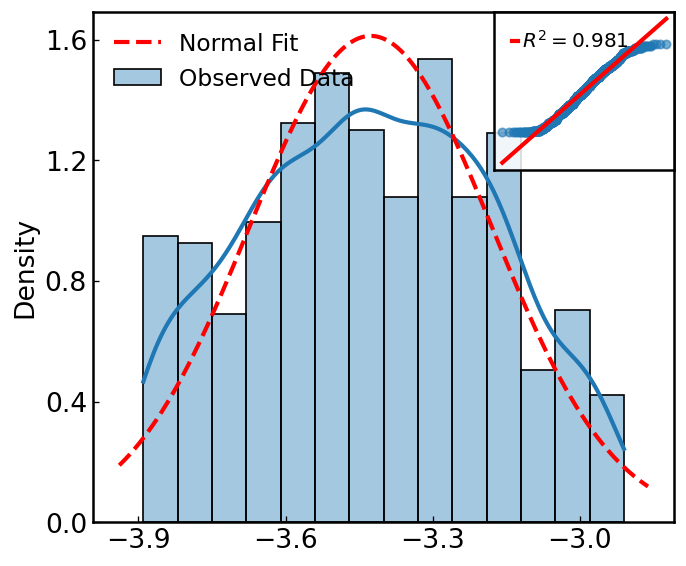

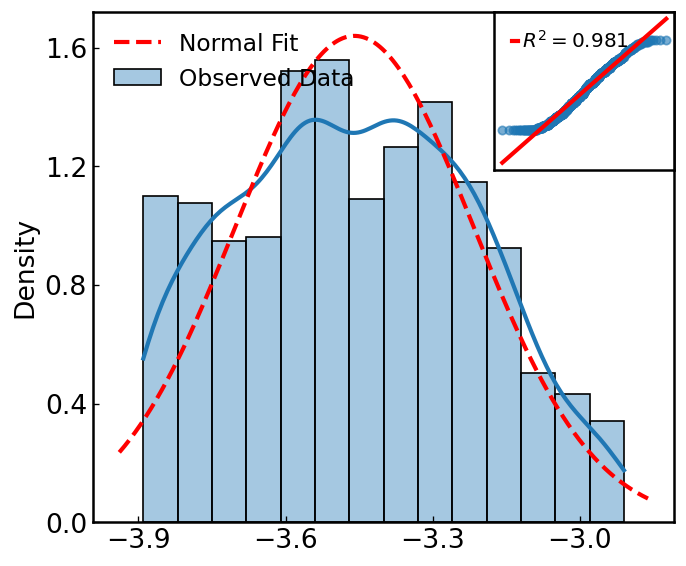

In [8]:
# Cell 8: Diagnostic Plots (Peak Distribution + Q-Q Inset)

for group_name, data in trace_features_all.items():
    fig, ax_main = plt.subplots(
        figsize=(PLOT_CONFIG["FIG_WIDTH_SINGLE"], PLOT_CONFIG["FIG_HEIGHT_SINGLE"])
    )

    # Histogram + KDE (density)
    sns.histplot(
        data, kde=True, stat="density", ax=ax_main, alpha=0.4,
        line_kws={"lw": 2.5}, label="Observed Data",
    )

    # Normal fit overlay
    xmin, xmax = ax_main.get_xlim()
    x = np.linspace(xmin, xmax, 200)
    mu, std = np.mean(data), np.std(data)
    ax_main.plot(
        x, stats.norm.pdf(x, mu, std), "r--", lw=2.5, label="Normal Fit",
    )

    # Axes formatting
    ax_main.set_ylabel("Density", fontsize=PLOT_CONFIG["FONT_SIZE_LABEL"])
    ax_main.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    ax_main.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
    ax_main.tick_params(axis="both", which="major", direction="in")
    ax_main.legend(loc="upper left", frameon=False, fontsize=PLOT_CONFIG["FONT_SIZE_LEGEND"])

    # Full box frame
    for spine in ax_main.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.5)

    # Q-Q inset (normality check)
    ax_inset = ax_main.inset_axes([0.69, 0.69, 0.31, 0.31])
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist="norm", plot=None)

    ax_inset.plot(osm, osr, "o", markersize=5, alpha=0.6)
    ax_inset.plot(
        osm, slope * osm + intercept, "r-", lw=2.5, label=fr"$R^2={r**2:.3f}$"
    )
    ax_inset.legend(loc="upper left", frameon=False, fontsize=12, handlelength=0.3, handletextpad=0.2)

    # Minimal inset styling
    ax_inset.set_xticks([])
    ax_inset.set_yticks([])
    ax_inset.set_xlabel("")
    ax_inset.set_ylabel("")
    for spine in ax_inset.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.5)
    ax_inset.set_facecolor((1, 1, 1, 0.85))

    plt.tight_layout()

    # Save figure 
    save_name = f"Diag_TraceModes_MoZn.png"
    plt.savefig(save_name, bbox_inches="tight")
    plt.show()

N_A (Traces),N_B (Traces),Conclusion,Mean Difference,95% CI Low,95% CI High,p-value
1219,1220,Significance,0.0331,0.0136,0.0526,8.851e-04


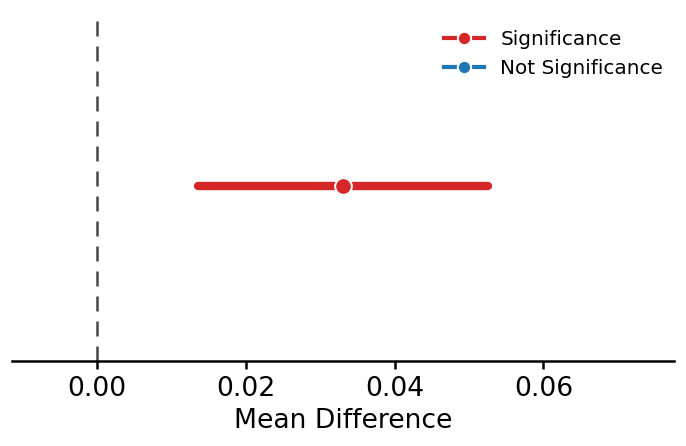

In [9]:
# Cell 9: Significance Testing

group_names = list(groups_data_raw.keys())
all_pairs = list(itertools.combinations(group_names, 2))

for group_A, group_B in all_pairs:
    # Analysis windows
    min_A, max_A = RANGE_CONFIG[group_A]
    min_B, max_B = RANGE_CONFIG[group_B]

    # Use all traces
    vals_A = get_trace_modes_from_matrix(groups_data_raw[group_A], min_A, max_A, TRACE_HIST_BIN_WIDTH)
    vals_B = get_trace_modes_from_matrix(groups_data_raw[group_B], min_B, max_B, TRACE_HIST_BIN_WIDTH)

    if len(vals_A) < 5 or len(vals_B) < 5:
        continue

    # Welch t-test + CI for mean difference
    _, p_t = welch_t_test(vals_A, vals_B)
    mean_diff, ci_sig = calculate_welch_ci(vals_A, vals_B, conf_level=(1 - ALPHA))

    df_res = pd.DataFrame([{
        "N_A (Traces)": len(vals_A), "N_B (Traces)": len(vals_B),
        "Conclusion": "Significance" if p_t < ALPHA else "Not Significance",
        "Mean Difference": mean_diff,
        "95% CI Low": ci_sig[0], "95% CI High": ci_sig[1], "p-value": p_t,
    }])

    # Result table
    format_dict = {
        "Mean Difference": "{:.4f}", "95% CI Low": "{:.4f}", "95% CI High": "{:.4f}", "p-value": "{:.3e}",
    }
    display(
        df_res[
            ["N_A (Traces)", "N_B (Traces)", "Conclusion",
             "Mean Difference", "95% CI Low", "95% CI High", "p-value"]
        ].style.format(format_dict).hide(axis="index")
    )

    # CI plot
    fig = plt.figure(figsize=(PLOT_CONFIG["FIG_WIDTH_SINGLE"], 4))
    ax = fig.add_subplot(111)
    
    col_sig = "#d62728"
    col_nsig = "#1f77b4"
    is_sig = df_res.loc[0, "Conclusion"] == "Significance"
    color = col_sig if is_sig else col_nsig
    alpha_line = 1.0 if is_sig else 0.85
    ax.axvline(0.0, linestyle=(0, (6, 4)), color='#333333', lw=1.5, alpha=0.9, zorder=1)

    ax.plot(
        [df_res.loc[0, "95% CI Low"], df_res.loc[0, "95% CI High"]], [0, 0], color=color,
        lw=5, alpha=alpha_line, solid_capstyle='round', zorder=2
    )
    ax.plot(
        df_res.loc[0, "Mean Difference"], 0, "o", color=color,
        ms=PLOT_CONFIG["MARKER_SIZE"], markeredgecolor="white", markeredgewidth=1.2, zorder=3,
    )
    
    x_high = float(df_res['95% CI High'].max())
    x_low = float(df_res['95% CI Low'].min())
    ax.set_xlim(x_low-0.025, x_high+0.025)
    
    ax.set_xlabel("Mean Difference", fontsize=PLOT_CONFIG["FONT_SIZE_LABEL"])
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    ax.set_yticks([])
    ax.set_yticklabels([])
    ax.tick_params(axis="y", left=False, length=0)
    ax.tick_params(axis='x', which='major', width=1.5, length=5)
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.5)
    legend_elements = [
        Line2D([0], [0], color=col_sig, marker="o", lw=2.5,
               label="Significance", ms=8, mec="white", mew=1.2),
        Line2D([0], [0], color=col_nsig, marker="o", lw=2.5,
               label="Not Significance", ms=8, mec="white", mew=1.2),
    ]
    ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.01, 1.0), frameon=False, fontsize=12)

    plt.tight_layout()
    plt.savefig("Significance_Testing_MoZn", bbox_inches="tight")
    plt.show()

N_A (Traces),N_B (Traces),Conclusion,Mean Difference,TOST 90% CI Low,TOST 90% CI High
1219,1220,Equivalence,0.0331,0.0167,0.0495


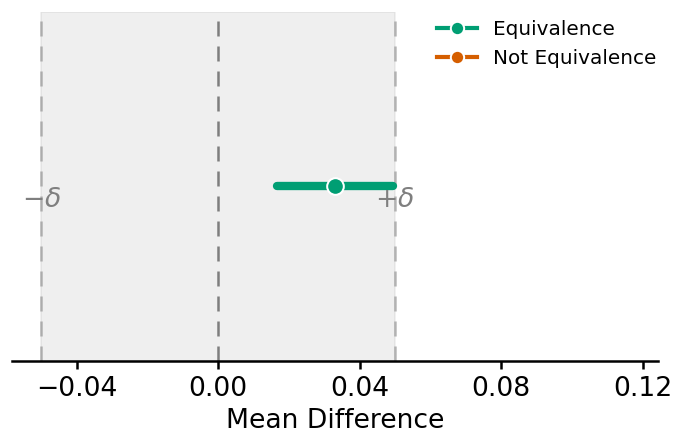

In [10]:
# Cell 10: Equivalence Testing (TOST)

delta_val = DELTAS["delta"]

group_names = list(groups_data_raw.keys())
all_pairs = list(itertools.combinations(group_names, 2))

for group_A, group_B in all_pairs:
    # Analysis windows
    min_A, max_A = RANGE_CONFIG[group_A]
    min_B, max_B = RANGE_CONFIG[group_B]

    # Use all traces
    vals_A = get_trace_modes_from_matrix(groups_data_raw[group_A], min_A, max_A, TRACE_HIST_BIN_WIDTH)
    vals_B = get_trace_modes_from_matrix(groups_data_raw[group_B], min_B, max_B, TRACE_HIST_BIN_WIDTH)

    if len(vals_A) < 5 or len(vals_B) < 5:
        continue

    # TOST via Welch (90% CI for alpha=0.05)
    is_equiv, (low, high) = tost_welch(vals_A, vals_B, delta_val, ALPHA)
    mean_diff = np.mean(vals_A) - np.mean(vals_B)

    df_res = pd.DataFrame([{
        "N_A (Traces)": len(vals_A), "N_B (Traces)": len(vals_B),
        "Conclusion": "Equivalence" if is_equiv else "Not Equivalence",
        "Mean Difference": mean_diff, "TOST 90% CI Low": low, "TOST 90% CI High": high,
    }])

    # Result table
    format_dict = {
        "Mean Difference": "{:.4f}", "TOST 90% CI Low": "{:.4f}", "TOST 90% CI High": "{:.4f}",
    }

    display(
        df_res[
            ["N_A (Traces)", "N_B (Traces)", "Conclusion", "Mean Difference", "TOST 90% CI Low", "TOST 90% CI High"]
        ].style.format(format_dict).hide(axis="index")
    )

    # Equivalence plot
    fig = plt.figure(figsize=(PLOT_CONFIG["FIG_WIDTH_SINGLE"], 4))
    ax = fig.add_subplot(111)

    col_eq  = '#009E73'   
    col_neq = '#D55E00'   
    col_bd  = '#7f7f7f'
    
    is_eq = df_res.loc[0, "Conclusion"] == "Equivalence"
    color = col_eq if is_eq else col_neq

    ax.axvspan(-delta_val, delta_val, color=col_bd, alpha=0.12, zorder=0)
    dash = (0, (6, 4))
    ax.axvline(-delta_val, linestyle=dash, color=col_bd, lw=1.5, alpha=0.55, zorder=1)
    ax.axvline( delta_val, linestyle=dash, color=col_bd, lw=1.5, alpha=0.55, zorder=1)
    ax.axvline(0.0, linestyle=dash, color='#333333', lw=1.5, alpha=0.6, zorder=1)

    alpha_line = 1.0 if is_eq else 0.85

    ax.plot(
        [df_res.loc[0, "TOST 90% CI Low"], df_res.loc[0, "TOST 90% CI High"]], [0, 0], color=color,
        lw=5, alpha=alpha_line, solid_capstyle='round', zorder=2
    )
    ax.plot(
        df_res.loc[0, "Mean Difference"], 0, "o", color=color,
        ms=PLOT_CONFIG["MARKER_SIZE"], markeredgecolor="white", markeredgewidth=1.2, zorder=3,
    )

    x_high = float(df_res['TOST 90% CI High'].max())
    x_low = float(df_res['TOST 90% CI Low'].min())
    ax.set_xlim(x_low-0.075, x_high+0.075)
    
    ax.set_xlabel("Mean Difference", fontsize=PLOT_CONFIG["FONT_SIZE_LABEL"])
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))

    # Remove all y-axis marks and labels
    ax.set_yticks([])
    ax.set_yticklabels([])
    ax.tick_params(axis="y", left=False, length=0)
    ax.tick_params(axis='x', which='major', width=1.5, length=5)
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.5)
    
    # ±delta labels
    trans = ax.get_xaxis_transform()
    ax.text(-delta_val, 0.5, r"$-\delta$", ha="center", va="top", transform=trans,
            fontsize=PLOT_CONFIG["FONT_SIZE_TICK"], color=col_bd, fontweight="bold")
    ax.text(delta_val, 0.5, r"$+\delta$", ha="center", va="top", transform=trans,
            fontsize=PLOT_CONFIG["FONT_SIZE_TICK"], color=col_bd, fontweight="bold")

    legend_elements = [
        Line2D([0], [0], color=col_eq, marker="o", lw=2.5,
               label="Equivalence", ms=8, mec="white", mew=1.2),
        Line2D([0], [0], color=col_neq, marker="o", lw=2.5,
               label="Not Equivalence", ms=8, mec="white", mew=1.2),
    ]
    
    ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.01, 1.0), ncol=1, 
              frameon=False, fontsize=12, borderaxespad=0.0)
    plt.tight_layout()
    plt.savefig("Equivalence_Testing_MoZn", bbox_inches="tight")
    plt.show()


N_A (Traces),N_B (Traces),Median Difference,p-value,Sig Conclusion,95% CI Low,95% CI High,Equiv Conclusion,TOST 90% CI Low,TOST 90% CI High
1219,1220,0.0400,1.233e-03,Significance,0.0200,0.0600,Not Equivalence,0.0200,0.0600


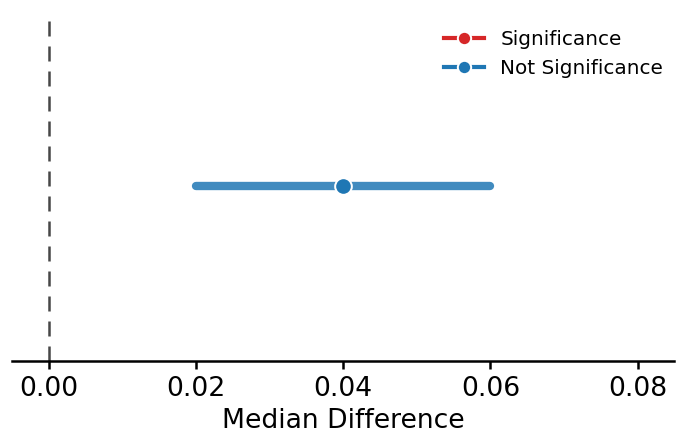

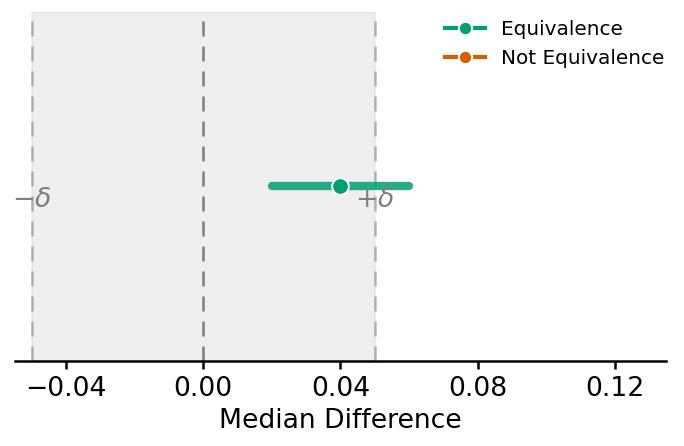

In [11]:
# Cell 11: Non-Parametric Analysis (Mann-Whitney + HL)

delta_val = DELTAS["delta"]

group_names = list(groups_data_raw.keys())
all_pairs = list(itertools.combinations(group_names, 2))

for group_A, group_B in all_pairs:
    # Analysis windows
    min_A, max_A = RANGE_CONFIG[group_A]
    min_B, max_B = RANGE_CONFIG[group_B]

    # Use all traces
    vals_A = get_trace_modes_from_matrix(groups_data_raw[group_A], min_A, max_A, TRACE_HIST_BIN_WIDTH)
    vals_B = get_trace_modes_from_matrix(groups_data_raw[group_B], min_B, max_B, TRACE_HIST_BIN_WIDTH)

    if len(vals_A) < 5 or len(vals_B) < 5:
        continue

    # Mann-Whitney U p-value (two-sided)
    try:
        _, p_mw = mannwhitneyu(vals_A, vals_B, alternative="two-sided")
    except Exception:
        p_mw = 1.0

    # Hodges-Lehmann estimate + CIs from asymptotic rank method
    hl_est, ci_95 = calculate_asymptotic_hl_ci(vals_A, vals_B, alpha=0.05)
    _, ci_90 = calculate_asymptotic_hl_ci(vals_A, vals_B, alpha=0.10)

    is_sig = p_mw < ALPHA
    is_equiv = (ci_90[0] > -delta_val) and (ci_90[1] < delta_val)

    df_final = pd.DataFrame([{
        "N_A (Traces)": len(vals_A), "N_B (Traces)": len(vals_B),
        "Median Difference": hl_est, "p-value": p_mw,
        "Sig Conclusion": "Significance" if is_sig else "Not Significance",
        "95% CI Low": ci_95[0], "95% CI High": ci_95[1],
        "Equiv Conclusion": "Equivalence" if is_equiv else "Not Equivalence",
        "TOST 90% CI Low": ci_90[0], "TOST 90% CI High": ci_90[1],
    }])

    # Result table
    format_dict = {
        "Median Difference": "{:.4f}", "p-value": "{:.3e}",
        "95% CI Low": "{:.4f}", "95% CI High": "{:.4f}",
        "TOST 90% CI Low": "{:.4f}", "TOST 90% CI High": "{:.4f}",
    }
    cols = [
        "N_A (Traces)", "N_B (Traces)",
        "Median Difference", "p-value", "Sig Conclusion", "95% CI Low", "95% CI High",
        "Equiv Conclusion", "TOST 90% CI Low", "TOST 90% CI High",
    ]
    display(df_final[cols].style.format(format_dict).hide(axis="index"))

    # Significance (95% CI)
    fig_sig, ax_sig = plt.subplots(figsize=(PLOT_CONFIG["FIG_WIDTH_SINGLE"], 4))

    col_sig = "#d62728"
    col_nsig = "#1f77b4"
    is_sig = df_res.loc[0, "Conclusion"] == "Significance"
    color = col_sig if is_sig else col_nsig
    alpha_line = 1.0 if is_sig else 0.85

    ax_sig.axvline(0.0, linestyle=(0, (6, 4)), color='#333333', lw=1.5, alpha=0.9, zorder=1)

    ax_sig.plot(
        [df_final.loc[0, "95% CI Low"], df_final.loc[0, "95% CI High"]], [0, 0], color=color,
        lw=5, alpha=alpha_line, solid_capstyle='round', zorder=2
    )
    ax_sig.plot(
        df_final.loc[0, "Median Difference"], 0, "o", color=color,
        ms=PLOT_CONFIG["MARKER_SIZE"], markeredgecolor="white", markeredgewidth=1.2, zorder=3,
    )
    
    x_high_sig = float(df_final['95% CI High'].max())
    x_low_sig = float(df_final['95% CI Low'].min())
    ax_sig.set_xlim(x_low_sig-0.025, x_high_sig+0.025)
    
    ax_sig.set_xlabel("Median Difference", fontsize=PLOT_CONFIG["FONT_SIZE_LABEL"])
    ax_sig.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    ax_sig.set_yticks([])
    ax_sig.set_yticklabels([])
    ax_sig.tick_params(axis="y", left=False, length=0)
    ax_sig.tick_params(axis='x', which='major', width=1.5, length=5)
    
    ax_sig.spines["top"].set_visible(False)
    ax_sig.spines["right"].set_visible(False)
    ax_sig.spines["left"].set_visible(False)
    ax_sig.spines['bottom'].set_linewidth(1.5)
    legend_elements_sig = [
        Line2D([0], [0], color=col_sig, marker="o", lw=2.5,
               label="Significance", ms=8, mec="white", mew=1.2),
        Line2D([0], [0], color=col_nsig, marker="o", lw=2.5,
               label="Not Significance", ms=8, mec="white", mew=1.2),
    ]
    ax_sig.legend(handles=legend_elements_sig, loc='upper right', bbox_to_anchor=(1.01, 1.0), frameon=False, fontsize=12)

    plt.tight_layout()
    plt.savefig("NonParam_Sig_MoZn", bbox_inches="tight")
    plt.show()

    # Equivalence (90% CI within ±δ)
    fig_tost, ax_tost = plt.subplots(figsize=(PLOT_CONFIG["FIG_WIDTH_SINGLE"], 4))

    col_eq  = '#009E73'   
    col_neq = '#D55E00'   
    col_bd  = '#7f7f7f'
    
    is_eq = df_res.loc[0, "Conclusion"] == "Equivalence"
    color = col_eq if is_eq else col_neq

    ax_tost.axvspan(-delta_val, delta_val, color=col_bd, alpha=0.12, zorder=0)
    dash = (0, (6, 4))
    ax_tost.axvline(-delta_val, linestyle=dash, color=col_bd, lw=1.5, alpha=0.55, zorder=1)
    ax_tost.axvline( delta_val, linestyle=dash, color=col_bd, lw=1.5, alpha=0.55, zorder=1)
    ax_tost.axvline(0.0, linestyle=dash, color='#333333', lw=1.5, alpha=0.6, zorder=1)

    ax_tost.plot(
        [df_final.loc[0, "TOST 90% CI Low"], df_final.loc[0, "TOST 90% CI High"]], [0, 0], color=color,
        lw=5, alpha=alpha_line, solid_capstyle='round', zorder=2
    )
    ax_tost.plot(
        df_final.loc[0, "Median Difference"], 0, "o", color=color,
        ms=PLOT_CONFIG["MARKER_SIZE"], markeredgecolor="white", markeredgewidth=1.2, zorder=3,
    )

    x_high_tost = float(df_final['TOST 90% CI High'].max())
    x_low_tost = float(df_final['TOST 90% CI Low'].min())
    ax_tost.set_xlim(x_low_tost-0.075, x_high_tost+0.075)
    
    ax_tost.set_xlabel("Median Difference", fontsize=PLOT_CONFIG["FONT_SIZE_LABEL"])
    ax_tost.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))

    # Remove all y-axis marks and labels
    ax_tost.set_yticks([])
    ax_tost.set_yticklabels([])
    ax_tost.tick_params(axis="y", left=False, length=0)
    ax_tost.tick_params(axis='x', which='major', width=1.5, length=5)
    
    ax_tost.spines["top"].set_visible(False)
    ax_tost.spines["right"].set_visible(False)
    ax_tost.spines["left"].set_visible(False)
    ax_tost.spines['bottom'].set_linewidth(1.5)
    
    # ±delta labels
    trans = ax_tost.get_xaxis_transform()
    ax_tost.text(-delta_val, 0.5, r"$-\delta$", ha="center", va="top", transform=trans,
            fontsize=PLOT_CONFIG["FONT_SIZE_TICK"], color=col_bd, fontweight="bold")
    ax_tost.text(delta_val, 0.5, r"$+\delta$", ha="center", va="top", transform=trans,
            fontsize=PLOT_CONFIG["FONT_SIZE_TICK"], color=col_bd, fontweight="bold")

    legend_elements_tost = [
        Line2D([0], [0], color=col_eq, marker="o", lw=2.5,
               label="Equivalence", ms=8, mec="white", mew=1.2),
        Line2D([0], [0], color=col_neq, marker="o", lw=2.5,
               label="Not Equivalence", ms=8, mec="white", mew=1.2),
    ]
    
    ax_tost.legend(handles=legend_elements_tost, loc='upper right', bbox_to_anchor=(1.01, 1.0), ncol=1, 
              frameon=False, fontsize=12, borderaxespad=0.0)

    plt.tight_layout()
    plt.savefig("NonParam_TOST_MoZn", bbox_inches="tight")
    plt.show()


In [12]:
# Cell 12a: Posterior panel plotter (single axis)

def plot_posterior_panel(
    ax, posterior_data, rope_interval, m_val, group_A_label, group_B_label, forced_xlim,
):
    """
    Plot posterior density with:
      - ROPE and boundaries
      - P(Δ>0) and % in ROPE
      - HDI (95% + 50%) and median marker
      - Directional "Favors" arrows
    """

    # Density on a fixed x-grid (shared xlim across panels)
    density = stats.gaussian_kde(posterior_data, bw_method=0.3)
    x_grid = np.linspace(forced_xlim[0], forced_xlim[1], 1000)
    y_grid = density(x_grid)
    ymax = np.max(y_grid)

    # Style color
    color_dark_blue = '#4a90e2'
    color_text_prob = '#1f78b4'  
    color_text_rope = '#555555'  
    col_bd = '#7f7f7f'
    dash = (0, (6, 4))

    # ROPE region (background)
    ax.axvspan(rope_interval[0], rope_interval[1], color='#d9d9d9', alpha=0.2, zorder=0)

    # Density curve + fill by sign
    ax.plot(x_grid, y_grid, color='#1d3f72', lw=1.5, alpha=0.85, zorder=3)
    ax.fill_between(x_grid, 0, y_grid, where=(x_grid < 0), color=color_dark_blue, alpha=0.85, zorder=2)
    ax.fill_between(x_grid, 0, y_grid, where=(x_grid >= 0), color=color_dark_blue, alpha=0.85, zorder=2)

    # Reference line at 0
    ax.axvline(0.0, linestyle=dash, color='#333333', lw=1.5, alpha=0.6, zorder=4)

    # Probabilities (top corner, auto-left/right)
    prob_gt_0 = float(np.mean(posterior_data > 0))
    prob_in_rope = float(np.mean((posterior_data >= rope_interval[0]) & (posterior_data <= rope_interval[1])))

    center_mass = float(np.mean(posterior_data))
    mid_point = 0.5 * (forced_xlim[0] + forced_xlim[1])
    text_x, text_ha = (0.04, "left") if center_mass > mid_point else (0.96, "right")

    ax.text(
        text_x, 0.85, f"P($\\Delta$ > 0) = {prob_gt_0:.0%}", transform=ax.transAxes, color=color_text_prob,
        fontsize=PLOT_CONFIG["FONT_SIZE_LEGEND"], ha=text_ha, fontweight="bold", zorder=20,
    )
    ax.text(
        text_x, 0.72, f"% in ROPE = {prob_in_rope:.1%}", transform=ax.transAxes, color=color_text_rope,
        fontsize=PLOT_CONFIG["FONT_SIZE_LEGEND"], ha=text_ha, zorder=20,
    )

    # HDIs + median 
    median = np.median(posterior_data)
    hdi_95 = az.hdi(posterior_data, hdi_prob=0.95)

    y_offset = -0.05 * ymax

    # 95% HDI line + median dot
    ax.plot([hdi_95[0], hdi_95[1]], [y_offset, y_offset], color='black', lw=2.5, zorder=10)
    ax.plot(median, y_offset, 'o', color='black', ms=9, zorder=12)

    # ROPE boundaries
    ax.axvline(-delta_val, linestyle=dash, color=col_bd, lw=1.5, alpha=0.55, zorder=4)
    ax.axvline( delta_val, linestyle=dash, color=col_bd, lw=1.5, alpha=0.55, zorder=4)
    
    # ±delta labels
    trans = ax.get_xaxis_transform()
    ax.text(-delta_val, 0.5, r"$-\delta$", ha="center", va="top", transform=trans,
            fontsize=PLOT_CONFIG["FONT_SIZE_TICK"], color=col_bd, fontweight="bold")
    ax.text(delta_val, 0.5, r"$+\delta$", ha="center", va="top", transform=trans,
            fontsize=PLOT_CONFIG["FONT_SIZE_TICK"], color=col_bd, fontweight="bold")

    # “Favors” arrows
    # arrow_y = 1.05
    # ax.annotate(
    #     f"Favors {group_A_label}",
    #     xy=(0.02, arrow_y),
    #     xycoords="axes fraction",
    #     xytext=(0.45, arrow_y),
    #     textcoords="axes fraction",
    #     arrowprops=dict(arrowstyle="->", color="black", lw=2.5),
    #     ha="right",
    #     va="center",
    #     fontsize=PLOT_CONFIG["FONT_SIZE_LEGEND"],
    #     fontweight="bold",
    #     color="black",
    # )
    # ax.annotate(
    #     f"Favors {group_B_label}",
    #     xy=(0.98, arrow_y),
    #     xycoords="axes fraction",
    #     xytext=(0.55, arrow_y),
    #     textcoords="axes fraction",
    #     arrowprops=dict(arrowstyle="->", color="black", lw=2.5),
    #     ha="left",
    #     va="center",
    #     fontsize=PLOT_CONFIG["FONT_SIZE_LEGEND"],
    #     fontweight="bold",
    #     color="black",
    # )

    # Axes formatting
    ax.set_xlim(forced_xlim)
    ax.set_facecolor('white')
    ax.set_ylim(bottom=y_offset * 2.0, top=ymax * 1.5)

    ax.set_xlabel("Mean Difference", fontsize=PLOT_CONFIG["FONT_SIZE_LABEL"])
    ax.set_ylabel("Posterior Density", fontsize=PLOT_CONFIG["FONT_SIZE_LABEL"])


    ax.tick_params(axis='x', which='major', width=1.5, length=5, bottom=True, top=False)     
    ax.tick_params(axis='y', which='major', width=1.5, length=5, left=True, right=False)     
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.5)
    for side in ['bottom', 'left', 'top', 'right']:
        ax.spines[side].set_zorder(1000)

Auto-assigning NUTS sampler...
Initializing NUTS using adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [mu_P1, sigma_P1, mu_P2, sigma_P2, nu_minus_one]
Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 14 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


[Diagnostics] P1 vs P2 | divergences=0


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
difference_of_means,0.033,0.010,0.015,0.052,0.0,0.0,5294.0,2870.0,1.0
mu_P1,-3.426,0.007,-3.440,-3.414,0.0,0.0,5616.0,2855.0,1.0
mu_P2,-3.460,0.007,-3.473,-3.447,0.0,0.0,5653.0,2789.0,1.0


N_A (Traces),N_B (Traces),Mean Diff,95% HDI Low,95% HDI High,% in ROPE,P(P1 > P2)
1219,1220,0.0334,0.0144,0.0526,95.3%,100.0%


                     r_hat  ess_bulk  ess_tail
difference_of_means    1.0    5294.0    2870.0
mu_P1                  1.0    5616.0    2855.0
mu_P2                  1.0    5653.0    2789.0


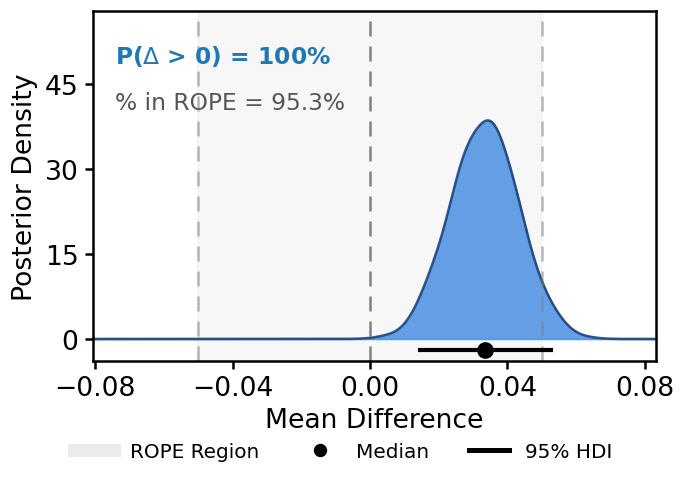

In [13]:
# Cell 12b: Bayesian Analysis

# Clear PyTensor cache
try:
    pytensor.clear_cache()
except Exception:
    pass

delta_val = DELTAS["delta"]
rope = (-delta_val, delta_val)

group_names = list(groups_data_raw.keys())
all_pairs = list(itertools.combinations(group_names, 2))

for group_A, group_B in all_pairs:
    # Analysis windows
    min_A, max_A = RANGE_CONFIG[group_A]
    min_B, max_B = RANGE_CONFIG[group_B]

    # Use ALL traces
    raw_A = groups_data_raw[group_A]
    raw_B = groups_data_raw[group_B]

    # Feature extraction
    vals_A = get_trace_modes_from_matrix(raw_A, min_A, max_A, TRACE_HIST_BIN_WIDTH)
    vals_B = get_trace_modes_from_matrix(raw_B, min_B, max_B, TRACE_HIST_BIN_WIDTH)

    # Skip if too few valid modes
    if len(vals_A) < 5 or len(vals_B) < 5:
        continue

    # Bayesian inference (Student-T two-group model)
    data_for_pair = {group_A: vals_A, group_B: vals_B}
    trace, _ = get_bayesian_posterior(data_for_pair, SEED)

    post_samples = trace.posterior["difference_of_means"].values.flatten()
    
    # Diagnostics
    if (trace is None) or ("difference_of_means" not in trace.posterior):
        continue

    div = int(np.sum(trace.sample_stats["diverging"].values))
    summ = az.summary(
        trace,
        var_names=["difference_of_means", f"mu_{group_A}", f"mu_{group_B}"],
    )

    print(f"[Diagnostics] {group_A} vs {group_B} | divergences={div}")
    display(summ)

    # Optional: skip if sampler looks unhealthy
    if div > 0:
        print("[Warning] Divergences detected; results may be unreliable. Skipping this pair.")
        continue
    
    # Posterior 
    post_samples = trace.posterior["difference_of_means"].values.flatten()

    # Posterior summary metrics
    hdi_95 = az.hdi(post_samples, hdi_prob=0.95)
    in_rope = float(np.mean((post_samples >= rope[0]) & (post_samples <= rope[1])))
    p_gt_0 = float(np.mean(post_samples > 0))

    df_bayes = pd.DataFrame(
        [{
            "N_A (Traces)": len(vals_A), "N_B (Traces)": len(vals_B), "Mean Diff": float(np.mean(post_samples)),
            "95% HDI Low": float(hdi_95[0]), "95% HDI High": float(hdi_95[1]), "% in ROPE": in_rope,
            f"P({group_A} > {group_B})": p_gt_0,
        }]
    )

    prob_col = f"P({group_A} > {group_B})"
    cols_to_show = ["N_A (Traces)", "N_B (Traces)", "Mean Diff", "95% HDI Low", "95% HDI High", "% in ROPE", prob_col]
    format_dict = {
        "Mean Diff": "{:.4f}", "95% HDI Low": "{:.4f}", "95% HDI High": "{:.4f}", "% in ROPE": "{:.1%}", prob_col: "{:.1%}",
    }

    display(df_bayes[cols_to_show].style.format(format_dict).hide(axis="index"))
    
    x_low  = float(min(hdi_95[0], rope[0]))   
    x_high = float(max(hdi_95[1], rope[1]))
    span = max(1e-9, x_high - x_low)
    pad  = 0.3 * span                         
    final_xlim = (x_low - pad, x_high + pad)
    
    fig, ax = plt.subplots(figsize=(PLOT_CONFIG["FIG_WIDTH_SINGLE"], 4))
    plot_posterior_panel(
        ax=ax, posterior_data=post_samples, rope_interval=rope, m_val=f"{len(vals_A)} vs {len(vals_B)}",  
        group_A_label=group_A, group_B_label=group_B, forced_xlim=final_xlim,
    )

    legend_elements = [
        Line2D([0], [0], color="#d9d9d9", lw=8, alpha=0.5, label="ROPE Region"),
        Line2D([0], [0], color="black", marker="o", ms=7, linestyle="None", label="Median"),
        Line2D([0], [0], color="black", lw=3, label="95% HDI"),
    ]
    fig.legend(
        handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, 0.08), ncol=3, frameon=False, fontsize=12,
    )
    
    print(summ[["r_hat", "ess_bulk", "ess_tail"]])
    plt.tight_layout()
    plt.savefig("Bayes_MoZn", bbox_inches="tight")
    plt.show()

Auto-assigning NUTS sampler...
Initializing NUTS using adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [mu_P1, sigma_P1, mu_P2, sigma_P2, nu_minus_one]
Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 9 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Auto-assigning NUTS sampler...
Initializing NUTS using adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [mu_P1, sigma_P1, mu_P2, sigma_P2, nu_minus_one]
Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 10 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Auto-assigning NUTS sampler...
Initializing NUTS using adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [mu_P1, sigma_P1, mu_P2, sigma_P2, nu_minus_one]
Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 10 seconds.
We recommend runnin

  Repeat 1/10 finished...


Auto-assigning NUTS sampler...
Initializing NUTS using adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [mu_P1, sigma_P1, mu_P2, sigma_P2, nu_minus_one]
Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 9 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Auto-assigning NUTS sampler...
Initializing NUTS using adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [mu_P1, sigma_P1, mu_P2, sigma_P2, nu_minus_one]
Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 10 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Auto-assigning NUTS sampler...
Initializing NUTS using adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [mu_P1, sigma_P1, mu_P2, sigma_P2, nu_minus_one]
Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 11 seconds.
We recommend runnin

  Repeat 2/10 finished...


Auto-assigning NUTS sampler...
Initializing NUTS using adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [mu_P1, sigma_P1, mu_P2, sigma_P2, nu_minus_one]
Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 9 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Auto-assigning NUTS sampler...
Initializing NUTS using adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [mu_P1, sigma_P1, mu_P2, sigma_P2, nu_minus_one]
Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 10 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Auto-assigning NUTS sampler...
Initializing NUTS using adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [mu_P1, sigma_P1, mu_P2, sigma_P2, nu_minus_one]
Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 11 seconds.
We recommend runnin

...

  Repeat 9/10 finished...


Auto-assigning NUTS sampler...
Initializing NUTS using adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [mu_P1, sigma_P1, mu_P2, sigma_P2, nu_minus_one]
Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 9 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Auto-assigning NUTS sampler...
Initializing NUTS using adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [mu_P1, sigma_P1, mu_P2, sigma_P2, nu_minus_one]
Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 10 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Auto-assigning NUTS sampler...
Initializing NUTS using adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [mu_P1, sigma_P1, mu_P2, sigma_P2, nu_minus_one]
Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 11 seconds.
We recommend runnin

  Repeat 10/10 finished...


N,p_mean,p_std,P(p<0.05),P(p>=0.05),ROPE_mean,ROPE_std,valid_repeats_p,valid_repeats_rope,valid_modes_A_mean,valid_modes_B_mean,rhat_mean,divergences_sum
100,3.082e-01,1.9e-01,10.0%,90.0%,57.7%,19.9%,10,10,100,100,1.000,0
200,4.254e-01,3.1e-01,20.0%,80.0%,76.8%,22.5%,10,10,200,200,1.001,0
300,2.316e-01,1.7e-01,20.0%,80.0%,82.1%,16.4%,10,10,300,300,1.001,0
400,1.959e-01,2.1e-01,20.0%,80.0%,88.0%,8.3%,10,10,400,400,1.001,0
500,1.732e-01,2.2e-01,30.0%,70.0%,90.0%,7.5%,10,10,500,500,1.001,0
600,1.026e-01,1.2e-01,40.0%,60.0%,92.1%,6.9%,10,10,600,600,1.001,0
700,5.281e-02,6.6e-02,80.0%,20.0%,90.7%,9.6%,10,10,700,700,1.000,0
800,2.877e-02,3.1e-02,80.0%,20.0%,88.1%,14.9%,10,10,800,800,1.001,0
900,2.351e-02,3.1e-02,80.0%,20.0%,90.1%,9.8%,10,10,900,900,1.001,0
1000,1.137e-02,1.4e-02,100.0%,0.0%,94.9%,4.0%,10,10,1000,1000,1.001,0


[Result] Sufficient Sample Size: N = 1100 (ROPE_mean = 0.956)


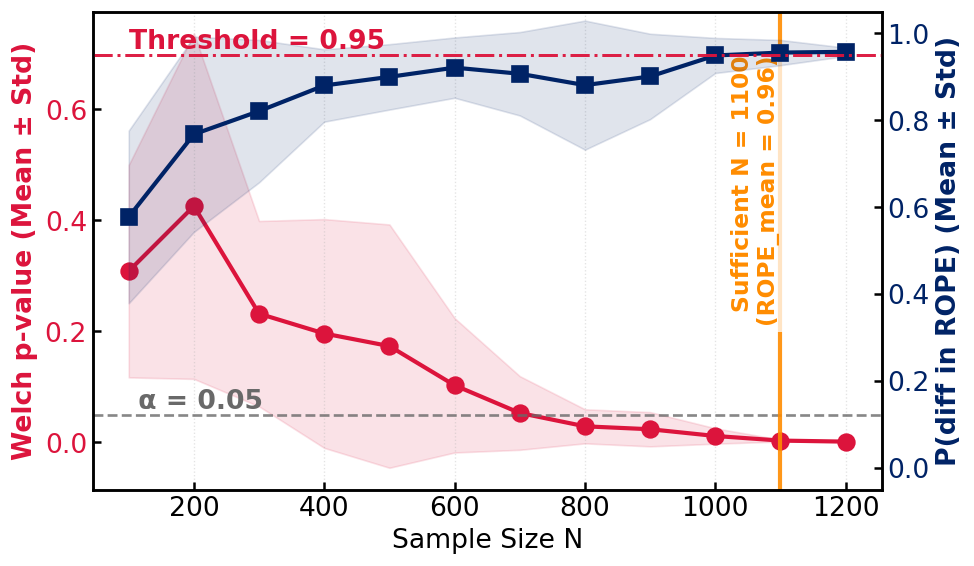

In [14]:
# Cell 13: Sequential Analysis
#   Goal: For each pair of groups, evaluate how inference stabilizes as sample size N increases.
#   Sufficient sample size criterion (UPDATED):
#        - Find smallest N such that ROPE_mean >= 0.95

# Experiment Config
N_START, N_END, N_STEP = 100, 1200, 100
N_LIST = list(range(N_START, N_END + 1, N_STEP))

REPEATS = 10
MIN_VALID_REPEATS = 5  # minimum valid repeats required to trust mean/std

delta_val = DELTAS["delta"]
rope = (-delta_val, delta_val)

# Helpers: aggregate over finite entries
def ratio_over_valid(x, thr, op="lt"):
    """Return fraction of valid entries satisfying condition, and #valid."""
    m = np.isfinite(x)
    n_valid = int(m.sum())
    if n_valid == 0:
        return np.nan, 0
    if op == "lt":
        return float(np.mean(x[m] < thr)), n_valid
    if op == "ge":
        return float(np.mean(x[m] >= thr)), n_valid
    raise ValueError("op must be 'lt' or 'ge'")

def mean_std_over_valid(x):
    """Return mean, std, and #valid over finite entries."""
    m = np.isfinite(x)
    n_valid = int(m.sum())
    if n_valid == 0:
        return np.nan, np.nan, 0
    xv = x[m]
    return float(np.mean(xv)), float(np.std(xv)), n_valid


group_names = list(groups_data_raw.keys())
all_pairs = list(itertools.combinations(group_names, 2))


# Main loop
for group_A, group_B in all_pairs:
    raw_A = groups_data_raw[group_A]
    raw_B = groups_data_raw[group_B]

    # Analysis window (explicit; no DEFAULT fallback)
    min_A, max_A = RANGE_CONFIG[group_A]
    min_B, max_B = RANGE_CONFIG[group_B]

    # Storage: (REPEATS, len(N_LIST))
    p_values = np.full((REPEATS, len(N_LIST)), np.nan, dtype=float)
    rope_probs = np.full((REPEATS, len(N_LIST)), np.nan, dtype=float)
    
    
    divergences = np.zeros((REPEATS, len(N_LIST)), dtype=int)
    rhat_diff = np.full((REPEATS, len(N_LIST)), np.nan, dtype=float)
    
    
    valid_counts_A = np.zeros((REPEATS, len(N_LIST)), dtype=int)
    valid_counts_B = np.zeros((REPEATS, len(N_LIST)), dtype=int)

    # Repeats: shuffle -> truncate
    for r in range(1, REPEATS + 1):
        seed_rep = SEED + r + 111
        rng_seq = np.random.default_rng(seed_rep)

        shuffled_A = raw_A[rng_seq.permutation(len(raw_A))]
        shuffled_B = raw_B[rng_seq.permutation(len(raw_B))]

        for j, N in enumerate(N_LIST):
            subA = shuffled_A[: min(N, len(raw_A))]
            subB = shuffled_B[: min(N, len(raw_B))]

            # Extract per-trace modes (hist mode peak positions)
            modes_A = get_trace_modes_from_matrix(
                subA, min_A, max_A, TRACE_HIST_BIN_WIDTH
            )
            modes_B = get_trace_modes_from_matrix(
                subB, min_B, max_B, TRACE_HIST_BIN_WIDTH
            )

            valid_counts_A[r-1, j] = len(modes_A)
            valid_counts_B[r-1, j] = len(modes_B)

            # Need enough valid modes to compute statistics
            if (len(modes_A) < 5) or (len(modes_B) < 5):
                continue

            # Welch p-value
            _, p_t = welch_t_test(modes_A, modes_B)
            p_values[r-1, j] = float(p_t)

            # Bayesian ROPE probability
            data_for_pair = {group_A: modes_A, group_B: modes_B}
            try:
                trace, _ = get_bayesian_posterior(data_for_pair, random_seed=seed_rep)
                if (trace is None) or ("difference_of_means" not in trace.posterior):
                    continue

                divergences[r-1, j] = int(np.sum(trace.sample_stats["diverging"].values))

                rhat_val = az.rhat(trace, var_names=["difference_of_means"])
                rhat_diff[r-1, j] = float(rhat_val["difference_of_means"].values)

                if divergences[r-1, j] > 0:
                    continue

                post = trace.posterior["difference_of_means"].values.flatten()
                rope_probs[r-1, j] = float(np.mean((post >= rope[0]) & (post <= rope[1])))

            except Exception:
                continue

        print(f"  Repeat {r}/{REPEATS} finished...")

    # Aggregate across repeats at each N
    p_mean = np.full(len(N_LIST), np.nan, dtype=float)
    p_std = np.full(len(N_LIST), np.nan, dtype=float)
    rope_mean = np.full(len(N_LIST), np.nan, dtype=float)
    rope_std = np.full(len(N_LIST), np.nan, dtype=float)

    frac_sig = np.full(len(N_LIST), np.nan, dtype=float)
    frac_nonsig = np.full(len(N_LIST), np.nan, dtype=float)
    n_valid_p = np.zeros(len(N_LIST), dtype=int)
    n_valid_rope = np.zeros(len(N_LIST), dtype=int)

    for j in range(len(N_LIST)):
        pm, ps, nv_p = mean_std_over_valid(p_values[:, j])
        rm, rs, nv_r = mean_std_over_valid(rope_probs[:, j])

        p_mean[j], p_std[j], n_valid_p[j] = pm, ps, nv_p
        rope_mean[j], rope_std[j], n_valid_rope[j] = rm, rs, nv_r

        # P(p<alpha) / P(p>=alpha), only if enough valid repeats
        if nv_p >= MIN_VALID_REPEATS:
            frac_sig[j], _ = ratio_over_valid(p_values[:, j], ALPHA, op="lt")
            frac_nonsig[j], _ = ratio_over_valid(p_values[:, j], ALPHA, op="ge")

    df_seq = pd.DataFrame(
        {
            "N": N_LIST, "p_mean": p_mean, "p_std": p_std, "P(p<0.05)": frac_sig, "P(p>=0.05)": frac_nonsig,
            "ROPE_mean": rope_mean, "ROPE_std": rope_std, "valid_repeats_p": n_valid_p, "valid_repeats_rope": n_valid_rope,
            "valid_modes_A_mean": np.mean(valid_counts_A, axis=0), "valid_modes_B_mean": np.mean(valid_counts_B, axis=0),
            "rhat_mean": np.nanmean(rhat_diff, axis=0), "divergences_sum": np.sum(divergences, axis=0),
        }
    )

    display(
        df_seq.style.format(
            {
                "p_mean": "{:.3e}", "p_std": "{:.1e}", "P(p<0.05)": "{:.1%}", "P(p>=0.05)": "{:.1%}",
                "ROPE_mean": "{:.1%}", "ROPE_std": "{:.1%}",
                "valid_repeats_p": "{:.0f}", "valid_repeats_rope": "{:.0f}",
                "valid_modes_A_mean": "{:.0f}", "valid_modes_B_mean": "{:.0f}",
                "rhat_mean": "{:.3f}", "divergences_sum": "{:.0f}",
            }
        ).hide(axis="index")
    )

    # Sufficient Sample Size (Mean-based criterion) Rule: smallest N with ROPE_mean >= 0.95 AND enough valid repeats
    sufficient_N = None
    for j, N in enumerate(N_LIST):
        if (n_valid_rope[j] >= MIN_VALID_REPEATS) and np.isfinite(rope_mean[j]) and (rope_mean[j] >= 0.95):
            sufficient_N = int(N)
            break

    if sufficient_N is None:
        print("[Info] No N satisfies: ROPE_mean >= 0.95 (with enough valid repeats).")
    else:
        j0 = N_LIST.index(sufficient_N)
        print(f"[Result] Sufficient Sample Size: N = {sufficient_N} (ROPE_mean = {rope_mean[j0]:.3f})")

    # Visualization: p-value + ROPE prob
    fig, ax1 = plt.subplots(
        figsize=(PLOT_CONFIG["FIG_WIDTH_SINGLE"] * 1.4, PLOT_CONFIG["FIG_HEIGHT_SINGLE"])
    )
    x = np.array(N_LIST)

    color_p = "#DC143C"
    color_rope = "#002366"
    color_alpha = "#696969"
    color_thresh = "#DC143C"  # red for 0.95 threshold line/text

    # Left axis: Welch p-value
    ax1.plot(x, p_mean, marker="o", color=color_p, lw=2.5, label="p-value (mean)")
    ax1.fill_between(x, p_mean - p_std, p_mean + p_std, color=color_p, alpha=0.12, label="p-value (±std)")
    ax1.axhline(ALPHA, color=color_alpha, linestyle="--", lw=1.6, alpha=0.8)
    ax1.text(x[0], ALPHA, f" α = {ALPHA}", color=color_alpha, fontweight="bold", va="bottom",fontsize=PLOT_CONFIG["FONT_SIZE_TICK"])

    ax1.set_xlabel("Sample Size N", fontsize=PLOT_CONFIG["FONT_SIZE_LABEL"])
    ax1.set_ylabel(
        "Welch p-value (Mean ± Std)",
        color=color_p,
        fontsize=PLOT_CONFIG["FONT_SIZE_LABEL"],
        fontweight="bold",
    )
    ax1.tick_params(axis="y", labelcolor=color_p, labelsize=PLOT_CONFIG["FONT_SIZE_TICK"])
    x_even = x[(x % 200) == 0]
    ax1.set_xticks(x_even)
    ax1.set_xticklabels([str(int(v)) for v in x_even], fontsize=PLOT_CONFIG["FONT_SIZE_TICK"])

    # Right axis: ROPE probability
    ax2 = ax1.twinx()
    ax2.plot(x, rope_mean, marker="s", color=color_rope, lw=2.5, label="ROPE Prob (mean)")
    ax2.fill_between(x, rope_mean - rope_std, rope_mean + rope_std, color=color_rope, alpha=0.12, label="ROPE Prob (±std)")

    # 0.95 threshold (red line + red label)
    ax2.axhline(0.95, color=color_thresh, linestyle="-.", lw=1.8, alpha=0.95)
    ax2.text(
        x[0],
        0.95,
        "Threshold = 0.95",
        color=color_thresh,
        fontweight="bold",
        ha="left",
        va="bottom",
        fontsize=PLOT_CONFIG["FONT_SIZE_TICK"]
    )

    ax2.set_ylabel(
        "P(diff in ROPE) (Mean ± Std)",
        color=color_rope,
        fontsize=PLOT_CONFIG["FONT_SIZE_LABEL"],
        fontweight="bold",
    )
    ax2.tick_params(axis="y", labelcolor=color_rope, labelsize=PLOT_CONFIG["FONT_SIZE_TICK"])
    ax2.set_ylim(-0.05, 1.05)

    # Mark sufficient N
    if sufficient_N is not None:
        ax1.axvline(sufficient_N, color="#FF8C00", linestyle="-", lw=2.5, alpha=0.9)
        j0 = N_LIST.index(sufficient_N)
        ax1.text(
            sufficient_N,
            ax1.get_ylim()[1] * 0.9,
            f"Sufficient N = {sufficient_N}\n(ROPE_mean = {rope_mean[j0]:.2f})",
            color="#FF8C00",
            rotation=90,
            va="top",
            ha="right",
            fontsize=14,
            fontweight="bold",
            bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"),
        )

    # Full box spines + tick marks on all sides
    for ax in (ax1, ax2):
        for side in ("top", "right", "bottom", "left"):
            ax.spines[side].set_visible(True)
            ax.spines[side].set_linewidth(1.5)

    # Ticks on all sides (no label on top/right)
    ax1.tick_params(axis="both", which="both", direction="in", top=False, right=False, width=1.5, length=5)
    ax2.tick_params(axis="both", which="both", direction="in", top=False, right=True,  width=1.5, length=5)

    ax1.grid(True, axis="x", linestyle=":", alpha=0.35)
    plt.tight_layout()

    # Save outputs
    run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
    plt.savefig("Sequential_Analysis_MoZn", bbox_inches="tight")
    plt.show()
    plt.close(fig)

    df_seq.to_csv("Sequential_Analysis_MoZn_summary.csv", index=False)

    npz_path = "Sequential_Analysis_MoZn_raw.npz"
    np.savez_compressed(
        npz_path,
        N_LIST=np.array(N_LIST, dtype=int),
        p_values=p_values, rope_probs=rope_probs,
        valid_counts_A=valid_counts_A, valid_counts_B=valid_counts_B,
        group_A=group_A, group_B=group_B,
    )

    meta = {
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "run_id": run_id,
        "group_A": group_A,
        "group_B": group_B,
        "N_START": N_START,
        "N_END": N_END,
        "N_STEP": N_STEP,
        "REPEATS": REPEATS,
        "MIN_VALID_REPEATS": MIN_VALID_REPEATS,
        "ALPHA": float(ALPHA),
        "delta_val": float(delta_val),
        "rope": [float(rope[0]), float(rope[1])],
        "TRACE_HIST_BIN_WIDTH": float(TRACE_HIST_BIN_WIDTH),
        "seed_base_SEED": int(SEED),
        "range_A": [float(min_A), float(max_A)],
        "range_B": [float(min_B), float(max_B)],
        "sufficient_N": None if sufficient_N is None else int(sufficient_N),
        "criterion": "ROPE_mean >= 0.95 (with enough valid repeats)",
    }
    json_path = "Sequential_Analysis_MoZn_meta.json"
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(meta, f, ensure_ascii=False, indent=2)